In [3]:
include(joinpath(@__DIR__,"..","..","src/numerics_ITensor_TFIM.jl"))
##Plotting

ENV["GKS_ENCODING"] = "utf-8"
using Plots
using DelimitedFiles

In [4]:

#Let's now define some Functions
function expectation_value(psi,O)
    #<psi|O|psi>
    return inner(psi',O,psi)
end

##Constants
#Lattice Size
L =100
J = 1;
J2 = 0;
g  = 1;
#DMRG Parameters
cutoff_dmrg = 1e-10;
nsweeps = 20;
maxdim= [10,20,100,100,200,400,400,400,600];
data = []
#Sites
sites = siteinds("S=1/2",L)

H = Integrable_TFIM(J,g)


MPO
[1] ((dim=3|id=907|"Link,l=1"), (dim=2|id=852|"S=1/2,Site,n=1")', (dim=2|id=852|"S=1/2,Site,n=1"))
[2] ((dim=3|id=907|"Link,l=1"), (dim=4|id=748|"Link,l=2"), (dim=2|id=841|"S=1/2,Site,n=2")', (dim=2|id=841|"S=1/2,Site,n=2"))
[3] ((dim=4|id=748|"Link,l=2"), (dim=4|id=13|"Link,l=3"), (dim=2|id=724|"S=1/2,Site,n=3")', (dim=2|id=724|"S=1/2,Site,n=3"))
[4] ((dim=4|id=13|"Link,l=3"), (dim=4|id=844|"Link,l=4"), (dim=2|id=228|"S=1/2,Site,n=4")', (dim=2|id=228|"S=1/2,Site,n=4"))
[5] ((dim=4|id=844|"Link,l=4"), (dim=4|id=625|"Link,l=5"), (dim=2|id=757|"S=1/2,Site,n=5")', (dim=2|id=757|"S=1/2,Site,n=5"))
[6] ((dim=4|id=625|"Link,l=5"), (dim=4|id=279|"Link,l=6"), (dim=2|id=171|"S=1/2,Site,n=6")', (dim=2|id=171|"S=1/2,Site,n=6"))
[7] ((dim=4|id=279|"Link,l=6"), (dim=4|id=962|"Link,l=7"), (dim=2|id=844|"S=1/2,Site,n=7")', (dim=2|id=844|"S=1/2,Site,n=7"))
[8] ((dim=4|id=962|"Link,l=7"), (dim=4|id=538|"Link,l=8"), (dim=2|id=74|"S=1/2,Site,n=8")', (dim=2|id=74|"S=1/2,Site,n=8"))
[9] ((dim=4|id=538|

In [5]:
#Finding Ground  state 
psi0 = random_mps(sites; linkdims=2)
energy,psi0 = dmrg(H,psi0;nsweeps,maxdim)


After sweep 1 energy=-126.31742946921264  maxlinkdim=8 maxerr=0.00E+00 time=10.179
After sweep 2 energy=-127.04158469218156  maxlinkdim=20 maxerr=5.59E-10 time=0.112
After sweep 3 energy=-127.19985391932315  maxlinkdim=78 maxerr=2.18E-16 time=14.943
After sweep 4 energy=-127.30419097861201  maxlinkdim=100 maxerr=4.09E-12 time=1.679
After sweep 5 energy=-127.31764775285153  maxlinkdim=200 maxerr=4.94E-14 time=6.011
After sweep 6 energy=-127.3210946928665  maxlinkdim=400 maxerr=3.58E-15 time=22.398
After sweep 7 energy=-127.32233554685152  maxlinkdim=400 maxerr=3.61E-14 time=37.731
After sweep 8 energy=-127.32312988452641  maxlinkdim=400 maxerr=3.11E-14 time=37.607
After sweep 9 energy=-127.32388016471761  maxlinkdim=600 maxerr=1.11E-14 time=66.022
After sweep 10 energy=-127.32465591706494  maxlinkdim=600 maxerr=1.26E-14 time=81.546
After sweep 11 energy=-127.32544553347876  maxlinkdim=600 maxerr=1.34E-14 time=84.053
After sweep 12 energy=-127.32621599561244  maxlinkdim=600 maxerr=1.47E-

(-127.32906037689237, MPS
[1] ((dim=2|id=852|"S=1/2,Site,n=1"), (dim=2|id=269|"Link,l=1"))
[2] ((dim=4|id=401|"Link,l=2"), (dim=2|id=841|"S=1/2,Site,n=2"), (dim=2|id=269|"Link,l=1"))
[3] ((dim=2|id=724|"S=1/2,Site,n=3"), (dim=8|id=637|"Link,l=3"), (dim=4|id=401|"Link,l=2"))
[4] ((dim=2|id=228|"S=1/2,Site,n=4"), (dim=16|id=985|"Link,l=4"), (dim=8|id=637|"Link,l=3"))
[5] ((dim=2|id=757|"S=1/2,Site,n=5"), (dim=32|id=869|"Link,l=5"), (dim=16|id=985|"Link,l=4"))
[6] ((dim=2|id=171|"S=1/2,Site,n=6"), (dim=58|id=516|"Link,l=6"), (dim=32|id=869|"Link,l=5"))
[7] ((dim=2|id=844|"S=1/2,Site,n=7"), (dim=82|id=822|"Link,l=7"), (dim=58|id=516|"Link,l=6"))
[8] ((dim=2|id=74|"S=1/2,Site,n=8"), (dim=109|id=975|"Link,l=8"), (dim=82|id=822|"Link,l=7"))
[9] ((dim=2|id=396|"S=1/2,Site,n=9"), (dim=134|id=780|"Link,l=9"), (dim=109|id=975|"Link,l=8"))
[10] ((dim=2|id=537|"S=1/2,Site,n=10"), (dim=155|id=799|"Link,l=10"), (dim=134|id=780|"Link,l=9"))
[11] ((dim=2|id=740|"S=1/2,Site,n=11"), (dim=172|id=106|"Link

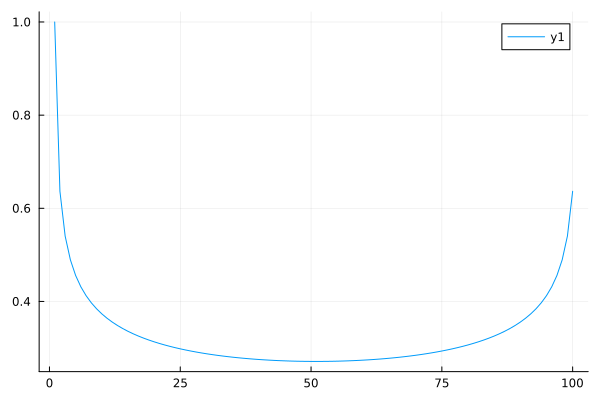

In [6]:
x=correlation_matrix(psi0,"X","X")

plot(x[1,:])

In [8]:
f= psi0
n = [i for i in 1:50]
N =inner(f', apply(op("X",sites[1])*op("X",sites[2]),f))
dat = []
for i in n[4:25]
    println(i)
    push!(dat,inner(f',apply(op("X",sites[1])*op("X",sites[2])*op("X",sites[i])*op("X",sites[i+1]),f))- N^2)
end


4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25


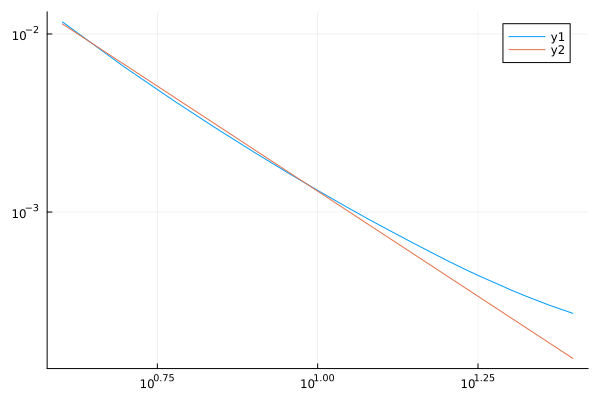

In [31]:
xdata = n[4:25]
ydata = dat

# Power law model: y = a * x^b
model(x, p) = p[1] .* x.^p[2]

# Initial guess for parameters [a, b]
p0 = [1.0, 1.0]
fit = curve_fit(model, xdata, ydata, p0)
a, b = fit.param

2-element Vector{Float64}:
  0.319919608748214
 -2.3984285014808018

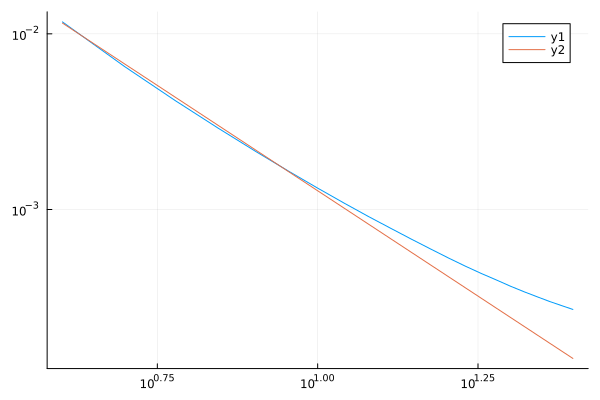

In [32]:
plot(n[4:25],[dat,(n[4:25].^(b))*a], xscale=:log10, yscale=:log10)

In [ ]:
f= psi0
n = [i for i in 1:50]
N =0 #inner(f', apply(op("X",sites[1])*op("X",sites[2]),f))
dat = []
for i in n[4:25]
    println(i)
    push!(dat,inner(f',apply(op("X",sites[1])*op("X",sites[2])*op("X",sites[3])*op("X",sites[i])*op("X",sites[i+1])*op("X",sites[i+3]),f))- N^2)
end

4
5
6
7
8
9
10
11
12
13
14
